In [1]:
# Run this cell once at the top of the notebook.

import numpy as np
from datascience import *

import matplotlib as plt
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')


# Lab 4: Data Stories with Brazil’s Climate & Development

<div style="border-left: 4px solid #0ea5e9; background:#f0f9ff; padding: 8px 12px; margin: 12px 0;">
  <strong>Info:</strong> In this lab, you’ll practice turning a <em>table</em> of data into a <strong>data story</strong>, not just a pretty chart.
</div>

You’ll use real indicators for Brazil: forests, energy, population, and poverty.

By the end of this lab, you should be able to:

- Choose variables that fit a story frame (not just “whatever is there”).
- Build visualizations that actually show a pattern, not noise.
- Explain your story using our four lenses:

1. <strong>Facts</strong> – what the data literally show.
2. <strong>Patterns</strong> – trends and relationships across time.
3. <strong>Implications</strong> – what might change or be affected.
4. <strong>Stakes</strong> – who is impacted and how.

There are two parts to this project:

- **Part A** – “together”: the notebook walks you through one story.
- **Part B** – you design your own story, following a similar pattern

### 1. Load and Clean the Brazil Climate Data

In [2]:
# Load the raw table
climate_raw = Table.read_table('climate-change_bra.csv')
climate_raw.show(5)


Country Name,Country ISO3,Year,Indicator Name,Indicator Code,Value
#country+name,#country+code,#date+year,#indicator+name,#indicator+code,#indicator+value+num
Brazil,BRA,2023,Agricultural land (sq. km),AG.LND.AGRI.K2,2367588
Brazil,BRA,2022,Agricultural land (sq. km),AG.LND.AGRI.K2,2367588
Brazil,BRA,2021,Agricultural land (sq. km),AG.LND.AGRI.K2,2367828
Brazil,BRA,2020,Agricultural land (sq. km),AG.LND.AGRI.K2,2368068


<div style="border-left: 4px solid #0ea5e9; background:#f0f9ff; padding: 8px 12px; margin: 12px 0;">
  <strong>Info:</strong> The file includes a header-like row with hashtags (e.g. <code>#country+name</code>).
  We only want the actual rows for Brazil.
</div>

**Task 1.1 – Basic cleaning**

We’ll keep only the rows where the country is clearly “Brazil”.


In [4]:
# TO DO: Keep only the Brazil rows and drop the metadata row. Call the new table: climate
climate = climate_raw.where('Country Name', are.equal_to('Brazil'))


climate.show(5)
climate.num_rows


Country Name,Country ISO3,Year,Indicator Name,Indicator Code,Value
Brazil,BRA,2023,Agricultural land (sq. km),AG.LND.AGRI.K2,2367588
Brazil,BRA,2022,Agricultural land (sq. km),AG.LND.AGRI.K2,2367588
Brazil,BRA,2021,Agricultural land (sq. km),AG.LND.AGRI.K2,2367828
Brazil,BRA,2020,Agricultural land (sq. km),AG.LND.AGRI.K2,2368068
Brazil,BRA,2019,Agricultural land (sq. km),AG.LND.AGRI.K2,2368308


1589

## Cleaning Step: Convert Population Values to Numbers

<div style="border-left: 4px solid #feba4f; background:#fce4bd; padding: 10px 14px; margin: 16px 0;">
  <strong>Warning:</strong> Some columns (for example, <code>Year, Value</code>)
  may appear as <em>strings</em> instead of numbers.<br><br>
  We need to convert these strings into numeric values so we can plot and compare them.
  Use the function below to clean the values and then apply it to the table.
</div>

### Task – Convert the population column to numbers

Complete these steps:
1. Define the cleaning function.  
2. Use <code>apply</code> to convert the values in your population table.  
3. Show the first few cleaned rows.


In [16]:
# 1. Define a cleaning function for population values.
#    It removes commas, strips whitespace, and converts to float.

def to_number(x):
    if type(x) is str:
        x = x.replace(',', '').strip()
        return float(x)
    else:
        return float(x)

# 2. Apply the cleaning function.
climate = climate.with_column(
    'Value', climate.apply(to_number, 'Value')
)
climate = climate.with_column(
    'Year', climate.apply(to_number, 'Year')
)

# 3. Preview the cleaned result.
climate.show(5)

# OPTIONAL: confirm the type changed
type(climate.column('Value').item(0))
type(climate.column('Year').item(0))


Country Name,Country ISO3,Year,Indicator Name,Indicator Code,Value
Brazil,BRA,2023,Agricultural land (sq. km),AG.LND.AGRI.K2,2.36759e+06
Brazil,BRA,2022,Agricultural land (sq. km),AG.LND.AGRI.K2,2.36759e+06
Brazil,BRA,2021,Agricultural land (sq. km),AG.LND.AGRI.K2,2.36783e+06
Brazil,BRA,2020,Agricultural land (sq. km),AG.LND.AGRI.K2,2.36807e+06
Brazil,BRA,2019,Agricultural land (sq. km),AG.LND.AGRI.K2,2.36831e+06


float

<div style="border-left: 4px solid #feba4f; background:#fce4bd; padding: 8px 12px; margin: 12px 0;">
  <strong>Data Checkin:</strong> Answer each of the following in a sentence or two
      <ol> <li> What are the column labels in this table? <br><i>
                your answer here 
            </i></li>
            <li> For this lab, which three labels are you MOST likely to care about? Why?<br><i>
                your answer here </i>
            </li>
</div>


In [17]:
# Lets look at all the different indicators available
indicators = climate.select('Indicator Name').group('Indicator Name')
indicators.show()


Indicator Name,count
Access to electricity (% of population),34
Agricultural irrigated land (% of total agricultural land),7
Agricultural land (% of land area),63
Agricultural land (sq. km),63
"Agriculture, forestry, and fishing, value added (% of GDP)",65
"Annual freshwater withdrawals, total (% of internal reso ...",36
"Annual freshwater withdrawals, total (billion cubic meters)",36
Arable land (% of land area),63
Average precipitation in depth (mm per year),62
Cereal yield (kg per hectare),63


### Task 2 – Pick candidate variables (guided)
<div style="border-left: 4px solid #22c55e; background:#ecfdf5; padding: 8px 12px; margin: 12px 0;">
  <strong>Important:</strong> Picking a good story starts with picking a good <em>angle</em>.
  We’re going to focus on how Brazil’s environment and development change over time.
</div>

We’ll use this framing:

> **Story frame A:** How have changes in Brazil’s forests and energy mix related to its population and poverty over time?

We won’t prove “cause and effect.” We’ll just build a serious, evidence-based story.

Consider which indicators *could* connect to this frame:

- Forests: 
  - `Forest area (% of land area)`
  - `Forest area (sq. km)`
- Agriculture & land:
  - `Agricultural land (% of land area)`
  - `Arable land (% of land area)`
- People & development:
  - `Population, total`
  - `Urban population (% of total population)`
  - `Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population)`
- Energy:
  - `Electric power consumption (kWh per capita)`
  - `Renewable energy consumption (% of total final energy consumption)`
  - `Renewable electricity output (% of total electricity output)`


<div style="border-left: 4px solid #feba4f; background:#fce4bd; padding: 10px 14px; margin: 16px 0;">
  <strong>Data Check-In:</strong> Complete the table below.<br>
  Select <em>four</em> indicators from the list above that might fit our story frame, and write one short phrase for why each might matter. We don\'t <bold> know </bold> that there is a pattern right now. We don\'t know if this information will be useful! But we have to begin hypothesizing using our reasoning skills to help decide where to start.
  <br><br>

  <table style="width: 100%; border-collapse: collapse;">
    <tr>
      <th style="text-align: left; padding: 6px; border-bottom: 2px solid #e2b26c;">Indicator</th>
      <th style="text-align: left; padding: 6px; border-bottom: 2px solid #e2b26c;">Why This Indicator Might Matter</th>
    </tr>
    <tr>
      <td>indicator 1</td>
      <td>purpose 1</td>
    </tr>
    <tr>
      <td>indicator 2</td>
      <td>purpose 2</td>
    </tr>
    <tr>
      <td>indicator 3</td>
      <td>purpose 3</td>
    </tr>
    <tr>
      <td>indicator 4</td>
      <td>purpose 4</td>
    </tr>
  </table>
</div>



In [18]:
# Add indicator names here if you pick different ones

forest = climate.where('Indicator Name', are.equal_to('Forest area (sq. km)')) \
                .select('Year', 'Value') \
                .relabel('Value', 'forest_sqkm') \
                .sort('Year')

ag_land = climate.where('Indicator Name', are.equal_to('Agricultural land (sq. km)')) \
                 .select('Year', 'Value') \
                 .relabel('Value', 'agricultural_sqkm') \
                 .sort('Year')

population = climate.where('Indicator Name', are.equal_to('Population, total')) \
                    .select('Year', 'Value') \
                    .relabel('Value', 'population_total') \
                    .sort('Year')

renewable = climate.where('Indicator Name',
                          are.equal_to('Renewable energy consumption (% of total final energy consumption)')) \
                   .select('Year', 'Value') \
                   .relabel('Value', 'renewable_pct') \
                   .sort('Year')

forest.show(5)


Year,forest_sqkm
1990,5.88898e+06
1991,5.85117e+06
1992,5.81336e+06
1993,5.77555e+06
1994,5.73774e+06


#### Check that your tables make sense
<div style="border-left: 4px solid #0ea5e9; background:#f0f9ff; padding: 8px 12px; margin: 12px 0;">
  <strong>Info:</strong> We now have four narrow tables with just <code>Year</code> and one variable each.
  Narrow tables make plotting easier and keep us focused.
</div>

For each of the four tables, answer:

1. What is the first and last year in the data?
2. Does the variable increase, decrease, or bounce around over time (just from quickly scanning the table)?


#### What a bad “pattern” looks like

We’re going to build a visualization that looks fancy but tells us almost nothing.

<div style="border-left: 4px solid #f97316; background:#fff7ed; padding: 8px 12px; margin: 12px 0;">
  <strong>Warning:</strong> If a chart doesn’t clearly show a pattern you can put into words,
  you should <em>not</em> keep building a story on top of it.
</div>

We’ll put two variables with completely different scales on the same axis: total population and renewable energy share.


Year,population_total,renewable_pct
1990,1.49143e+08,49.8
1991,1.51724e+08,48.9
1992,1.54275e+08,48.7
1993,1.56795e+08,48.2
1994,1.59265e+08,48.3


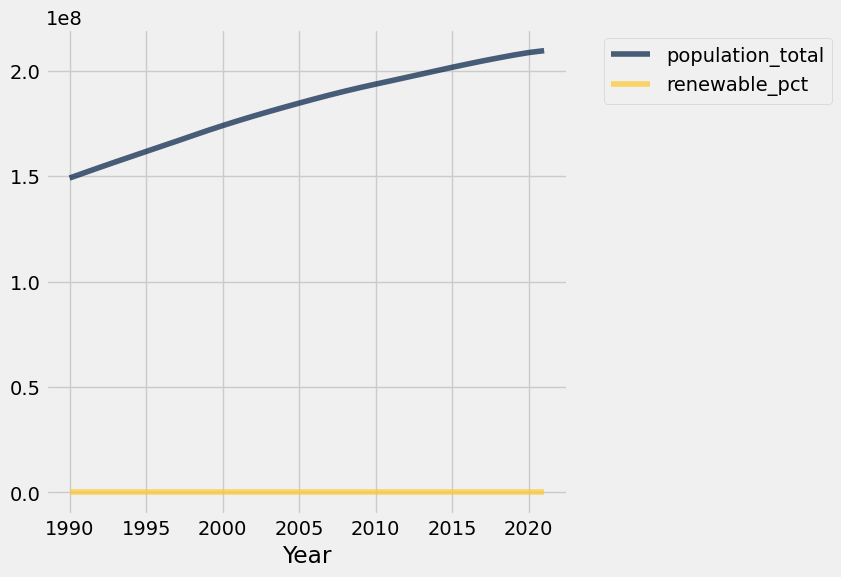

In [19]:
# Join population and renewable tables and make a bad plot on purpose

pop_ren = population.join('Year', renewable)
pop_ren.show(5)

# BAD PLOT: different scales squished together
pop_ren.plot('Year', ['population_total', 'renewable_pct'])


This viz is hard to read! As I've said previously, Datascience is built ontop of another plotting library called MatPlotLib. We can leverage MatplotLib to make the table more legible. Run the cell below to see an updated chart.

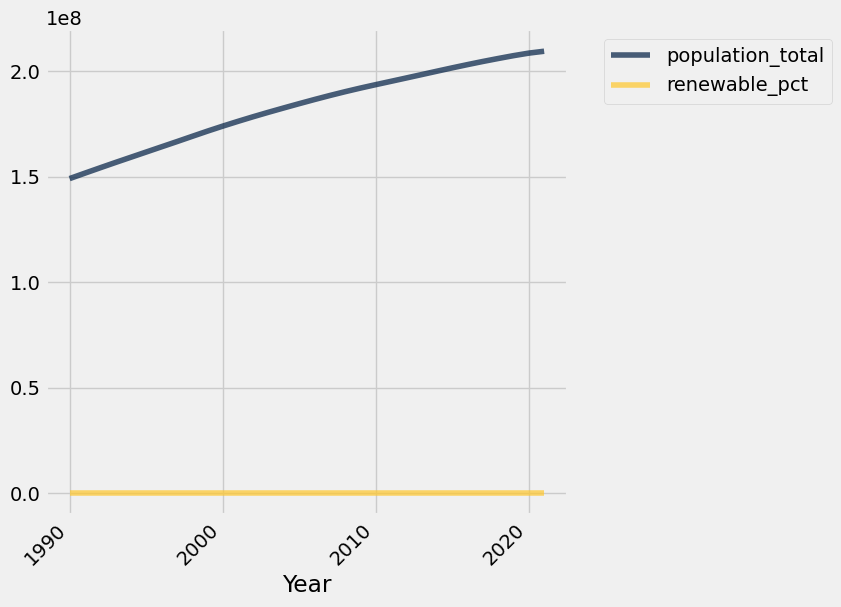

In [21]:

years = pop_ren.column('Year').astype(int) # Make the years ints instead of floats
tick_years = years[years % 10 == 0] # Select every 10 years

pop_ren.plot('Year', ['population_total', 'renewable_pct'])
plots.xticks(tick_years, rotation=45, ha='right'); # Display only every 10 years, rotate the labels 


#### Diagnose the failure - this is prettier, but the visual is still bad.
<div style="border-left: 4px solid #22c55e; background:#ecfdf5; padding: 8px 12px; margin: 12px 0;">
  <strong>Important:</strong> When you create a chart, your first job is to check:
  “Can I clearly describe at least one pattern in words?” If not, redesign.
</div>

<div style="border-left: 4px solid #feba4f; background:#fce4bd; padding: 8px 12px; margin: 12px 0;">
  <strong>Visualization Checkin:</strong> Answer briefly
      <ol> <li> What do you notice about the <b>scale</b> of the data in these two lines? <br><i>
                your answer here 
            </i></li>
            <li> Which variable dominates the chart? What happens to the other?<br><i>
                your answer here </i>
            </li>
          <li> Why would it be dangerous to build a big story from this specific plot?<br><i>
                your answer here </i>
            </li>
      </ol>
</div>



## Better visual choices

We’ll separate our questions:

1. How has Brazil’s **forest area** changed over time?
2. How has Brazil’s **population** changed over time?
3. How has the **renewable energy share** changed?

We’ll look at these one at a time so each pattern is visible.


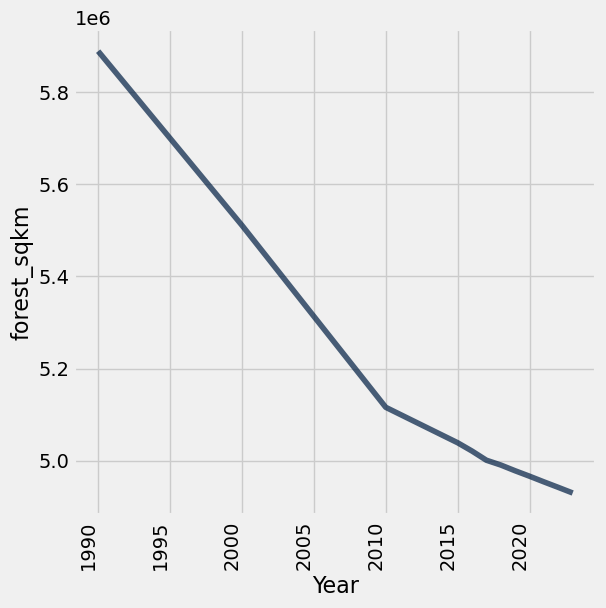

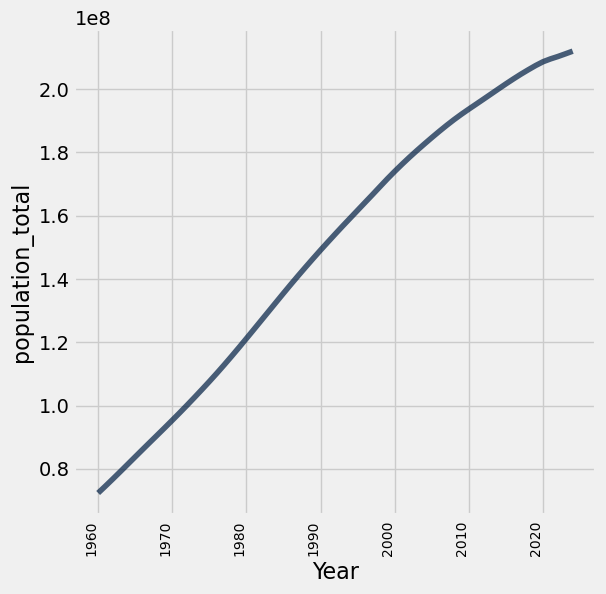

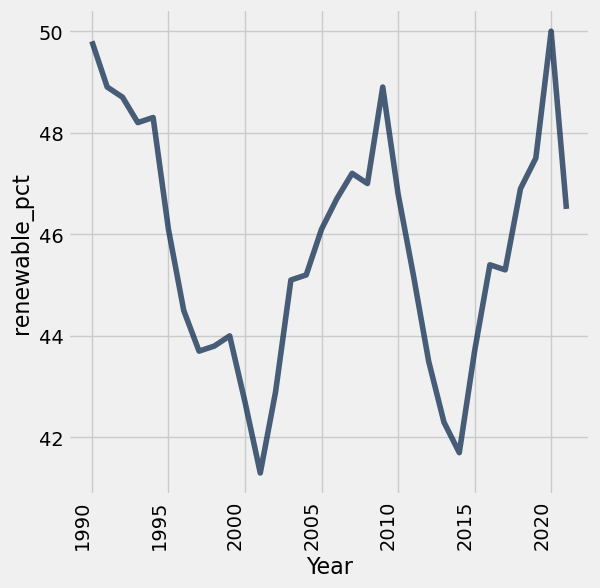

In [26]:

# Forest over time
forest.plot('Year', 'forest_sqkm')
plots.xticks(rotation=90, ha='right');   # rotate labels for readability

# Population over time
population.plot('Year', 'population_total')
plots.xticks(rotation=90, ha='right'); 
plots.xticks(rotation=90, ha='right', fontsize=10); # rotate labels for readability (still only sort of readable

# Renewable energy share over time
renewable.plot('Year', 'renewable_pct')
plots.xticks(rotation=90, ha='right');   # rotate labels for readability

# Add your tables below to look for relationships between plots. 




### Facts

<div style="border-left: 4px solid #feba4f; background:#fce4bd; padding: 8px 12px; margin: 12px 0;">
<b>Graph Analysis:</b> Complete the bulleted list for each plot (forests, population, renewables) <br>

List **2–3 specific facts** that are just about the graph, not your opinions. <br>

You might start sentences like:

- Between ____ and ____, the line goes up/down from about ____ to about ____.
- After year ____, the pattern changes from ___ to ___.

Use bullets:

- **Forests – facts:**
    - 1
    - 2
    - 3
- **Population – facts:**
    - 1
    - 2
    - 3
- **Renewables – facts:**
    - 1
    - 2
    - 3


### Patterns
<div style="border-left: 4px solid #feba4f; background:#fce4bd; padding: 8px 12px; margin: 12px 0;">
<b>Graph Analysis:</b> Now turn your facts into <b>patterns</b>. <br>

Write 1–2 sentences each:

1. A pattern statement about forests in Brazil.
2. A pattern statement about population.
3. A pattern statement about renewable energy.

Try to use comparative language: “while…”, “as…”, “compared to…”.

> Example structure (don’t copy this exactly):  
> “Brazil’s population grew from X to Y between ____ and ____, additionally, the forest area (in sq. km) changed by ______. This suggests __________.”


Year,forest_sqkm,population_total
1990,5.88898e+06,1.49143e+08
1991,5.85117e+06,1.51724e+08
1992,5.81336e+06,1.54275e+08
1993,5.77555e+06,1.56795e+08
1994,5.73774e+06,1.59265e+08


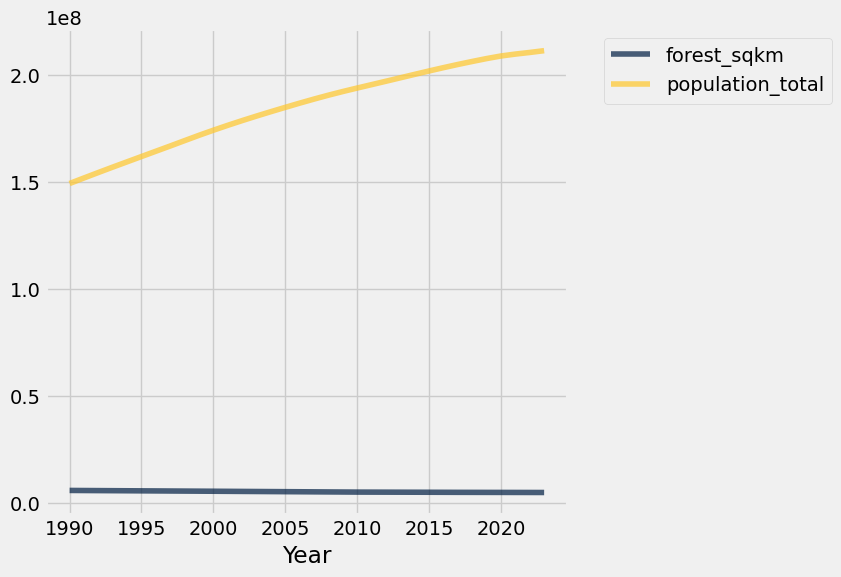

In [27]:
# Join forest and population on Year
forest_pop = forest.join('Year', population)
forest_pop.show(5)

# Quick check: visualize forest vs population over time on separate subplots
forest_pop.plot('Year', ['forest_sqkm', 'population_total'])


<div style="border-left: 4px solid #f97316; background:#fff7ed; padding: 10px 14px;">
  <strong>Warning:</strong> Even though we saw a correlation in the separate graphs, when we put them together the forestry values are imperceptable because these two indicators have very different scales.
  To compare their <em>patterns</em> fairly, normalize them first (e.g. index both to 100 in the first year).
</div>


### Compare the Direction of Change (Normalize First)

Plotting raw values of <code>forest_sqkm</code> and <code>population_total</code> on the same graph
doesn’t work well — one is in the millions and the other is in the hundreds of millions, so the
forest line gets flattened into almost zero.

To make their *patterns* comparable, we will **normalize** both series.

<div style="border-left: 4px solid #0ea5e9; background:#f0f9ff; padding: 8px 12px; margin: 12px 0;">
  <strong>Info:</strong>What does “normalize” mean here?<br><br>
  We will choose a baseline year (the first year in the table) and set its value to <strong>100</strong>.
  All other years will be expressed as a percentage of that baseline.<br><br>
  • If a value becomes <strong>120</strong>, it means it increased by 20% from the starting year.<br>
  • If a value becomes <strong>90</strong>, it means it decreased by 10% from the starting year.<br><br>
  This lets us compare <em>change over time</em> even if the original units and magnitudes are very different.
</div>

### Why is this statistically OK?

- We are not changing the meaning of the data — we’re changing the **units** so both variables fit on the same visual scale.  
- Each indicator still preserves its pattern: rising, falling, steady, or nonlinear.  
- We are comparing **relative change**, not absolute value. This is what my story frame (direction, timing, rate of change) cares about.  
- This is a standard method in economics, public health, climate science, and demography when comparing indicators with very different scales.

In the cell below, I have done a demo of how we can normalize the data.

<div style="border-left: 4px solid #0ea5e9; background:#f0f9ff; padding: 8px 12px; margin: 12px 0;">
  <strong>Note:</strong> Order of Operations<br>
I joined the data befre doing my normalization - this is important! This ensures that both datasets are starting at the same year at 100. If we had done it the other way around, the population dataset (which has many more years of data) would appear to be starting around 250 when in actuality the 100 value existed, but was dropped by the join.



Year,forest_sqkm,population_total
1990,5.88898e+06,1.49143e+08
1991,5.85117e+06,1.51724e+08
1992,5.81336e+06,1.54275e+08
1993,5.77555e+06,1.56795e+08
1994,5.73774e+06,1.59265e+08


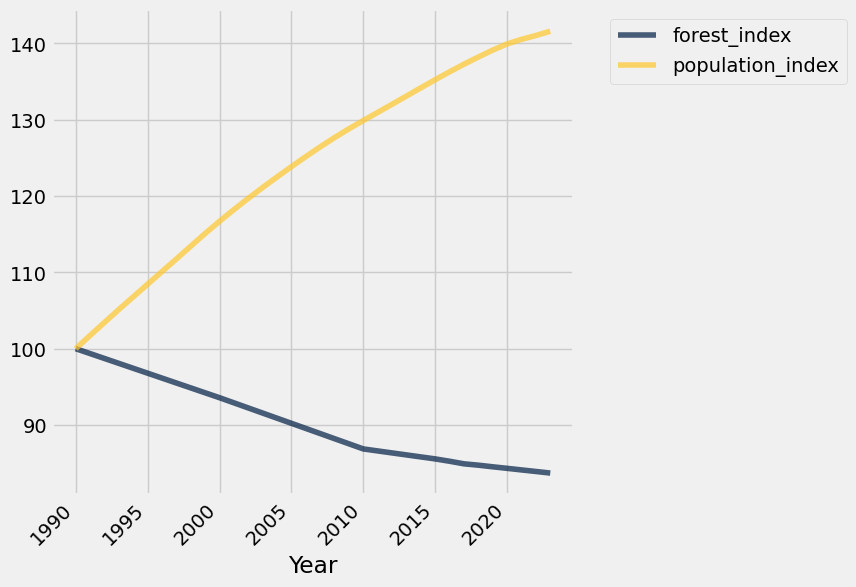

In [28]:
# Step 1 — Sort each table by Year
forest_sorted = forest.sort('Year')
population_sorted = population.sort('Year')


# Step 2 — Join the tables on Year (only shared years remain)
combined = forest_sorted.select('Year', 'forest_sqkm') \
    .join('Year', population_sorted.select('Year', 'population_total')) \
    .sort('Year')

combined.show(5)   # sanity check: first year should be 1990

# Step 3 — Define the index (normalization) function
def index(values):
    return (values / values.item(0)) * 100

# Step 4 — Normalize both indicators AFTER the join
combined_indexed = combined.with_columns(
    'forest_index', index(combined.column('forest_sqkm')),
    'population_index', index(combined.column('population_total'))
)

# Step 5 — Plot the normalized lines
combined_indexed.plot('Year', ['forest_index', 'population_index'])

from matplotlib import pyplot as plt
plt.xticks(rotation=45, ha='right');



### Compare directions, not just lines

<div style="border-left: 4px solid #feba4f; background:#fce4bd; padding: 8px 12px; margin: 12px 0;">
<strong>Data Viz analysis:</strong> 
Even if the scales are different, you can still compare the <b>direction</b>:

- Are forests and population both increasing?
    - *your response here*
- Does one level off while the other keeps changing?
    - *your response here*
- Are there time periods where their patterns look different?
    - *your response here*

Write 3–4 sentences that compare the patterns over time, focusing on
<strong>direction and timing</strong>, not exact numbers. 

*your response here*


## Pause & Rethink: Is There Another Way to See the Relationship?

Look again at your normalized line plot.  
You can clearly compare **how each indicator changes over time**, but that may not tell the whole story.

Before we move into Implications and Stakes, take a moment to think like a data scientist:

<div style="border-left: 4px solid #9b7e48; background:#fff9f0; padding: 10px 14px; margin: 16px 0;">
  <strong>Important:</strong> When two variables both change over time, the shape of their lines
  does NOT automatically tell you how the variables relate to one another. A plot doesn’t just show information it also decides what information
  <em>not</em> to show. When looking at our graphs,  we should ask:
  <br>
  “What does this view make visible, and what does it hide?”<br>
  Sometimes you need a second view of the same data.
</div>

### Your Task: Explore Alternatives

<div style="border-left: 4px solid #feba4f; background:#fce4bd; padding: 10px 14px; margin: 16px 0;">
  <strong>Data Check-In:</strong> Consider other ways to visualize these indicators.

**1. What does your normalized line plot reveal clearly?**  
  (Think: timing of change, direction of change, turning points, acceleration/slowdown.)

  **2. What does the line plot hide or make hard to see?**  
  (Think: the direct relationship between the two variables; how forest and population relate
  <em>to each other</em> rather than to time.)

  **3. If your goal was to understand how forest area and population relate <em>directly</em>,  
  not just how each changed over time, what type of visualization might help?**  
  (Describe the idea in words — not code.)

  **4. What question might a second visualization answer that the line plot cannot answer?**
</div>
After you’ve answered these, use the code cell below to test the alternative you proposed.


In [29]:
# Try out the alternative visualization you described above.
# You may use combined or combined_indexed depending on the plot you want to try. 

#Note: Suggestions below are options. Decide if they make sense and how they might be useful!

# Examples of things you might try:
# combined.plot('forest_sqkm', 'population_total')    # scatter
# combined.scatter('forest_sqkm', 'population_total')
# combined.hist('forest_sqkm')

# TODO: Write your own line of code here:


## Compare Your Two Views

Now that you’ve generated a second visualization, compare it to your line plot.

<div style="border-left: 4px solid #0ea5e9; background:#f0f9ff; padding: 10px 14px; margin: 16px 0;">
  <strong>Reflection:</strong> Every visualization gives you one angle on the story.
  Seeing the same data from two angles helps you understand it more completely.
</div>

Answer the following:
<div style="border-left: 4px solid #feba4f; background:#fce4bd; padding: 10px 14px; margin: 16px 0;">
  <strong>Data Check-In:</strong> Consider other ways to visualize these indicators.

- What does your new visualization show that the line plot does NOT show?(Think: timing of change, direction of change, turning points, acceleration/slowdown.)
    - *your response here*

- What does the line plot show that the new visualization does NOT show?
    - *your response here*

- How do these two perspectives together give you a fuller picture of what happened in Brazil?
    - *your response here*


##  Implications and stakes

So far we have:

- Variables chosen to fit a frame.
- Clean(ish) data.
- Visuals with real patterns.
- Pattern statements.

Now we move into **Implications** and **Stakes**.

<div style="border-left: 4px solid #22c55e; background:#ecfdf5; padding: 8px 12px; margin: 12px 0;">
  <strong>Important:</strong> Implications and stakes are about <em>people</em> and <em>places</em>.
  They should still be grounded in the patterns you saw.
</div>

### Implications

<div style="border-left: 4px solid #feba4f; background:#fce4bd; padding: 8px 12px; margin: 12px 0;">
<strong>Analysis:</strong> Using your pattern statements, answer:

- If these trends continued for another 20–30 years, what might change
   for ecosystems in Brazil? (Think: forests, water, agriculture.)
       
        - *Your response here*
- What might change for people’s daily lives? (Think: energy access, rural vs urban life, poverty.)
       
        - *Your response here*

Be honest about uncertainty — it’s fine to say “might” and “could.”

### Stakes

Now be specific about **who** is affected and **how**.

Name at least **two groups** (for example: rural farmers, urban residents,
Indigenous communities, future generations, energy companies, etc.).

For each group, identify the stakes in terms of economy, society, or culture (or multiple!):
- *Your response here*
- *Your response here*

Brazil hosted a global conference on climate this month. That is a massive economic committment! Why is this important to them?
    
- *Your response here*


## You're done! Please upload a link to this notebook in Canvas.